In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Feature names (SPAMBASE)
feature_names = [
"word_freq_make","word_freq_address","word_freq_all","word_freq_3d","word_freq_our",
"word_freq_over","word_freq_remove","word_freq_internet","word_freq_order","word_freq_mail",
"word_freq_receive","word_freq_will","word_freq_people","word_freq_report","word_freq_addresses",
"word_freq_free","word_freq_business","word_freq_email","word_freq_you","word_freq_credit",
"word_freq_your","word_freq_font","word_freq_000","word_freq_money","word_freq_hp",
"word_freq_hpl","word_freq_george","word_freq_650","word_freq_lab","word_freq_labs",
"word_freq_telnet","word_freq_857","word_freq_data","word_freq_415","word_freq_85",
"word_freq_technology","word_freq_1999","word_freq_parts","word_freq_pm","word_freq_direct",
"word_freq_cs","word_freq_meeting","word_freq_original","word_freq_project","word_freq_re",
"word_freq_edu","word_freq_table","word_freq_conference",
"char_freq_;","char_freq_(","char_freq_[","char_freq_!","char_freq_$","char_freq_#",
"capital_run_length_average","capital_run_length_longest","capital_run_length_total"
]

# Load dataset
data = pd.read_csv("spambase.data", header=None)
data.columns = feature_names + ["label"]

X = data.iloc[:, :-1]
y = data["label"]

In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [3]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

def get_metrics(model, X_train, y_train, X_test, y_test):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    y_train_prob = model.predict_proba(X_train)[:, 1]
    y_test_prob = model.predict_proba(X_test)[:, 1]

    return {
        "Train Accuracy": accuracy_score(y_train, y_train_pred),
        "Test Accuracy": accuracy_score(y_test, y_test_pred),
        "Train F1": f1_score(y_train, y_train_pred),
        "Test F1": f1_score(y_test, y_test_pred),
        "Train AUC": roc_auc_score(y_train, y_train_prob),
        "Test AUC": roc_auc_score(y_test, y_test_prob),
    }

In [4]:
from sklearn.ensemble import RandomForestClassifier

trees = [10, 50, 100, 500]
results = []

for t in trees:
    rf = RandomForestClassifier(
        n_estimators=t,
        random_state=42,
        n_jobs=-1
    )
    
    rf.fit(X_train, y_train)
    
    metrics = get_metrics(rf, X_train, y_train, X_test, y_test)
    metrics["Trees"] = t
    
    results.append(metrics)

rf_results = pd.DataFrame(results).set_index("Trees")

rf_results.round(4)

,Train Accuracy,Test Accuracy,Train F1,Test F1,Train AUC,Test AUC
Trees,,,,,,
10,0.9971,0.9418,0.9963,0.9241,1.0,0.9772
50,0.9997,0.9470,0.9996,0.9311,1.0,0.9852
100,0.9997,0.9513,0.9996,0.9371,1.0,0.9859
500,0.9997,0.9513,0.9996,0.9368,1.0,0.9863


In [33]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

dt.fit(X_train, y_train)

dt_metrics = get_metrics(dt, X_train, y_train, X_test, y_test)

dt_df = pd.DataFrame(dt_metrics, index=["Decision Tree"])
dt_df.round(4)

,Train Accuracy,Test Accuracy,Train F1,Test F1,Train AUC,Test AUC
Decision Tree,0.9997,0.9218,0.9996,0.9015,1.0,0.9193


In [38]:
comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest (10)",
        "Random Forest (50)",
        "Random Forest (100)",
        "Random Forest (500)"
    ],
    "Test Accuracy": [
        dt_metrics["Test Accuracy"],
        rf_results.loc[10]["Test Accuracy"],
        rf_results.loc[50]["Test Accuracy"],
        rf_results.loc[100]["Test Accuracy"],
        rf_results.loc[500]["Test Accuracy"]
    ],
    "Test F1": [
        dt_metrics["Test F1"],
        rf_results.loc[10]["Test F1"],
        rf_results.loc[50]["Test F1"],
        rf_results.loc[100]["Test F1"],
        rf_results.loc[500]["Test F1"]
    ],
    "Test AUC": [
        dt_metrics["Test AUC"],
        rf_results.loc[10]["Test AUC"],
        rf_results.loc[50]["Test AUC"],
        rf_results.loc[100]["Test AUC"],
        rf_results.loc[500]["Test AUC"]
    ]
})

comparison.round(4)

,Model,Test Accuracy,Test F1,Test AUC
0,Decision Tree,0.9218,0.9015,0.9193
1,Random Forest (10),0.9418,0.9241,0.9772
2,Random Forest (50),0.9470,0.9311,0.9852
3,Random Forest (100),0.9513,0.9371,0.9859
4,Random Forest (500),0.9513,0.9368,0.9863


In [35]:
rf_best = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_best.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [36]:
importances = rf_best.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feature_importance_df.head(10)

,Feature,Importance
51,char_freq_!,0.116482
52,char_freq_$,0.100767
6,word_freq_remove,0.079110
15,word_freq_free,0.059122
55,capital_run_length_longest,0.057796
56,capital_run_length_total,0.057398
54,capital_run_length_average,0.055244
20,word_freq_your,0.053949
24,word_freq_hp,0.042092
23,word_freq_money,0.032778


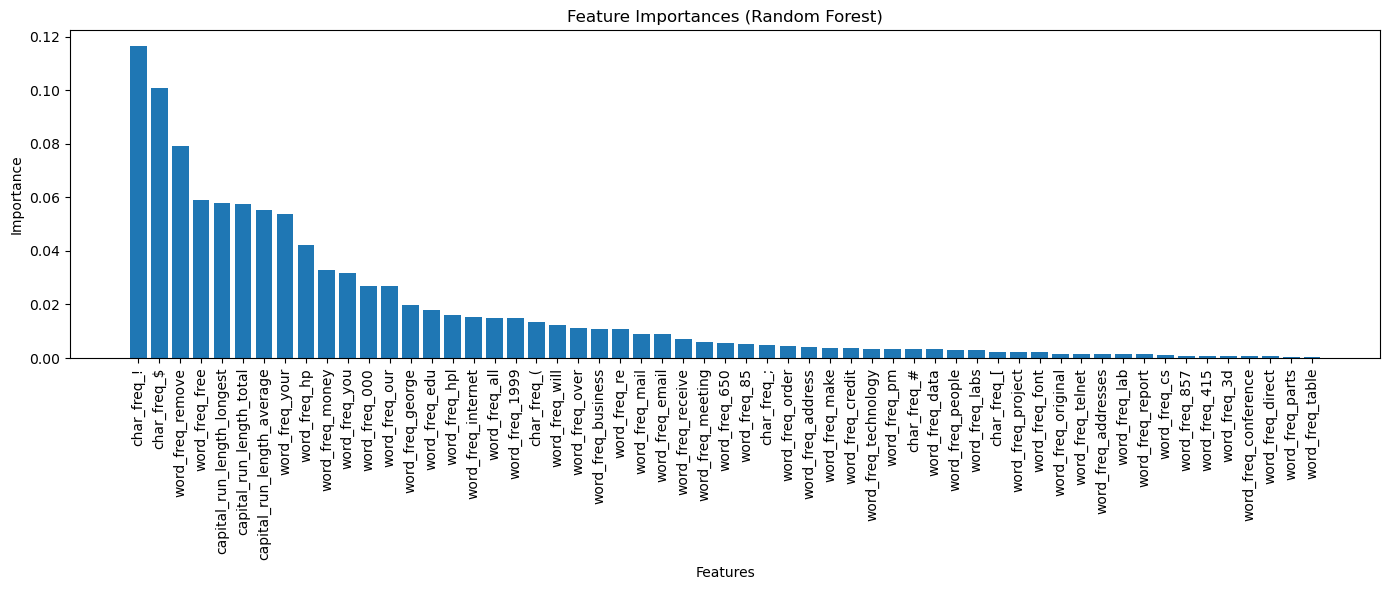

In [37]:
plt.figure(figsize=(14,6))

plt.bar(
    feature_importance_df["Feature"],
    feature_importance_df["Importance"]
)

plt.xticks(rotation=90)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importances (Random Forest)")

plt.tight_layout()
plt.show()